# **TUGAS MACHINE LEARNING**

JUDUL : PERBANDINGAN ALGORITMA DECISION TREE, RANDOM FOREST, DAN SUPPORT VECTOR MACHINE (SVM) DALAM KLASIFIKASI HARGA SMARTPHONE BERDASARKAN SPESIFIKASI

NAMA : MAISUN MUFLIHA APRILIA.M

NIM : F1G123049

KELAS : C  



### **1.Data Understanding**

### 1.1 Menjelaskan sumber data

Dataset yang digunakan dalam penelitian ini adalah Mobile Price Classification Dataset yang diperoleh dari platform Kaggle.

 https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification?resource=download&select=train.csv


Dataset ini berisi informasi spesifikasi teknis dari berbagai smartphone yang digunakan untuk mengklasifikasikan harga perangkat ke dalam beberapa kategori.

Dataset terdiri dari:

- 2000 data (record/observasi)

- 21 atribut (kolom), yang terdiri dari:

    - 20 fitur (variabel independen)
    - 1 variabel target (dependen) yaitu price_range
    
     

In [426]:
import pandas as pd
df = pd.read_csv('/content/train.csv')
df.head(2000)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


### 1.2 Menjelaskan fitur/variable dalam dataset

Dataset ini memiliki 21 atribut yang terdiri dari 20 fitur dan 1 variabel target. Berikut adalah penjelasan masing-masing variabel:

1. Fitur Performa

      - battery_power: kapasitas baterai (mAh)

      - clock_speed: kecepatan CPU (GHz)

      - n_cores: jumlah inti prosesor

      - ram: kapasitas RAM (MB)

2. Fitur Kamera

      - fc: resolusi kamera depan (MP)

      - pc: resolusi kamera belakang (MP)

3. Fitur Layar

      - px_height: tinggi resolusi layar

      - px_width: lebar resolusi layar

      - sc_h: tinggi layar

      - sc_w: lebar layar

      - touch_screen: layar sentuh (1 = ya, 0 = tidak)

4. Fitur Konektivitas

      - blue: Bluetooth

      - wifi: WiFi

      - hree_g: dukungan 3G

      - four_g: dukungan 4G

      - tdual_sim: dual SIM


5. Fitur Fisik

      - mobile_wt: berat smartphone

      - m_dep: ketebalan perangkat

6. Fitur Penyimpanan & Daya

      - int_memory: memori internal (GB)

      - talk_time: waktu penggunaan (jam)

7. Variabel Target

      - price_range: kategori harga smartphone

Variabel target ini memiliki 4 kelas, yaitu:

0 → Murah

1 → Menengah

2 → Menengah Tinggi

3 → Mahal

Sehingga penelitian ini termasuk dalam klasifikasi multiclass.

In [427]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

### 1.3 Menampilkan statistik deskriptif data

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai karakteristik data, seperti nilai rata-rata, nilai minimum, maksimum, serta penyebaran data.

Berdasarkan hasil analisis statistik deskriptif, diperoleh beberapa informasi penting sebagai berikut:

- Variabel RAM memiliki nilai rata-rata yang cukup tinggi dan rentang yang besar, menunjukkan variasi spesifikasi perangkat yang signifikan.

- Variabel battery_power menunjukkan distribusi yang cukup merata antara nilai minimum dan maksimum, sehingga dapat menjadi faktor penting dalam klasifikasi harga.

- Variabel seperti blue, wifi, dual_sim memiliki nilai biner (0 dan 1), yang menunjukkan keberadaan fitur tertentu pada smartphone.

- Variabel px_height dan px_width memiliki variasi nilai yang cukup besar, yang mencerminkan perbedaan resolusi layar antar perangkat.

- Tidak ditemukan nilai kosong (missing value), sehingga dataset siap digunakan tanpa proses imputasi data.

In [428]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


### **2. Data Preprocessing**

Tahap data preprocessing merupakan proses pembersihan dan persiapan data sebelum dilakukan pemodelan machine learning. Tahap ini bertujuan untuk meningkatkan kualitas data sehingga model yang dibangun dapat bekerja secara optimal.

### 2.1 Melihat Missing Value

In [429]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


Berdasarkan hasil pengecekan menggunakan fungsi isnull(), tidak ditemukan nilai kosong (missing value) pada dataset. Hal ini menunjukkan bahwa dataset dalam kondisi bersih dan tidak memerlukan proses imputasi data.

### 2.2 Melihat Outlier



In [430]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
outlier.sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,18
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


Outlier merupakan nilai ekstrem yang dapat mempengaruhi performa model. Untuk mendeteksi outlier, digunakan metode Interquartile Range (IQR).

Berdasarkan hasil deteksi outlier menggunakan metode IQR, ditemukan bahwa sebagian besar variabel tidak memiliki outlier. Beberapa variabel seperti fc dan px_height memiliki jumlah outlier yang sangat kecil, sehingga tidak memberikan dampak signifikan terhadap model.

Selain itu, nilai outlier yang tinggi pada variabel three_g disebabkan oleh karakteristik data yang bersifat biner, sehingga tidak relevan untuk dianalisis menggunakan metode IQR.

Dengan demikian, data tetap digunakan tanpa dilakukan penghapusan outlier.

Variabel yang memiliki outlier:

- fc (front camera) → terdapat 18 outlier

     Menunjukkan bahwa ada beberapa data dengan nilai kamera depan yang terlalu tinggi atau terlalu rendah dibanding data lainnya.

- px_height → terdapat 2 outlier

     Menunjukkan adanya resolusi layar yang tidak umum dibanding mayoritas data.

- three_g → terdapat 477 outlier

   Ini terlihat besar, tapi perlu diperhatikan:

     three_g adalah data biner (0 dan 1)

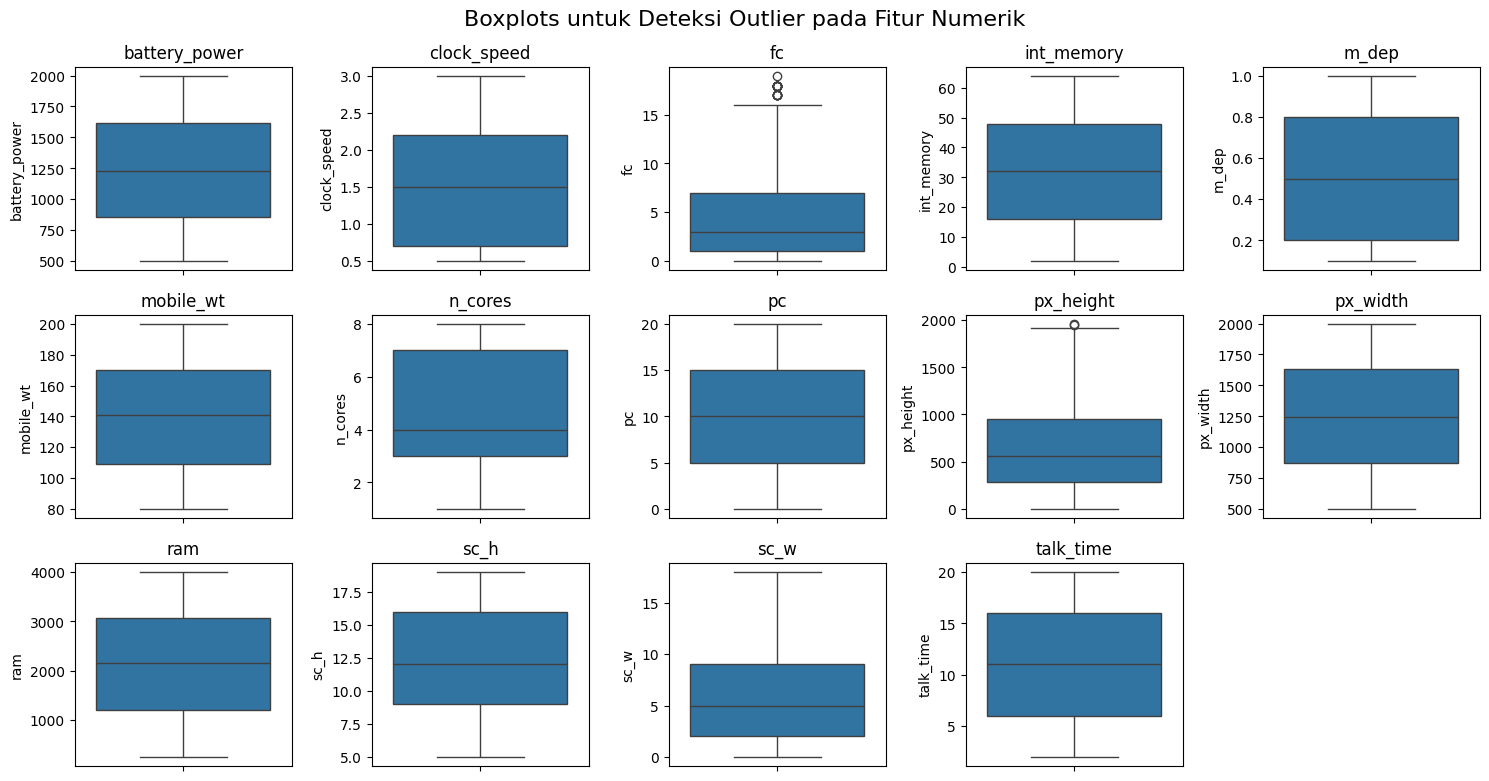

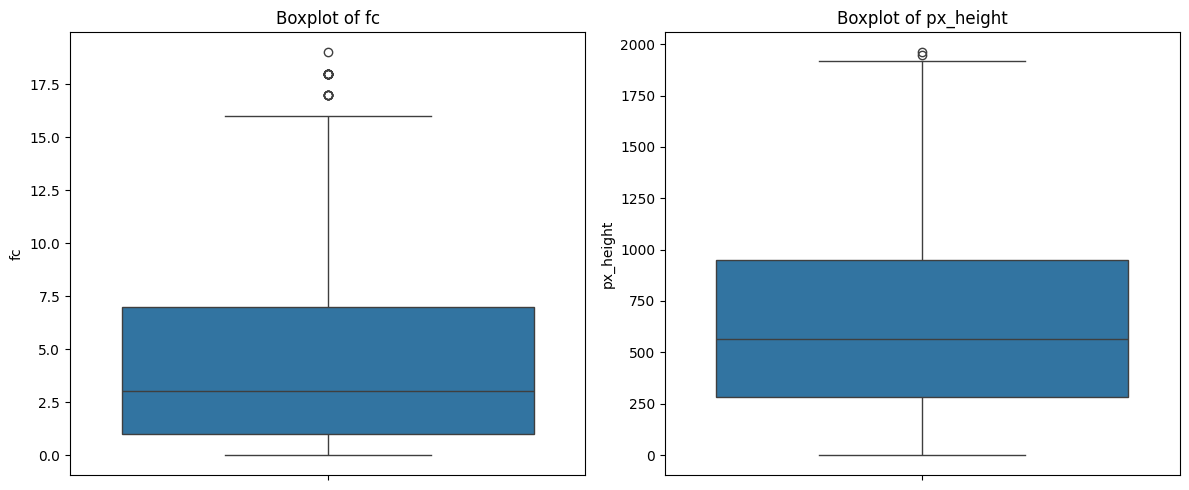

In [431]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/train.csv')

# Memilih kolom numerik untuk boxplot (kecuali variabel biner dan target)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi', 'price_range'])

# Membuat boxplot untuk setiap kolom numerik
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 5, i + 1) # Menyesuaikan grid subplot
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.suptitle('Boxplots untuk Deteksi Outlier pada Fitur Numerik', y=1.02, fontsize=16)
plt.show()

# Fokus pada kolom yang terdeteksi memiliki outlier
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['fc'])
plt.title('Boxplot of fc')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['px_height'])
plt.title('Boxplot of px_height')
plt.tight_layout()
plt.show()

### 2.3 Penanganan Outlier




In [432]:
import pandas as pd

df = pd.read_csv('/content/train.csv')

df_clean = df.copy()

# Re-define numerical_cols, binary_cols, and cols_to_clean to ensure they are in scope
numerical_cols = df_clean.drop('price_range', axis=1).select_dtypes(include=['int64', 'float64']).columns
binary_cols = [col for col in numerical_cols if df_clean[col].nunique() == 2]
cols_to_clean = [col for col in numerical_cols if col not in binary_cols]

for col in cols_to_clean:
    Q1 = df_clean[col].quantile(0.25);
    Q3 = df_clean[col].quantile(0.75);
    IQR = Q3 - Q1;

    lower_bound = Q1 - 1.5 * IQR;
    upper_bound = Q3 + 1.5 * IQR;

    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound);

Penanganan outlier dilakukan tanpa menghapus data secara langsung, melainkan menggunakan teknik capping untuk menjaga jumlah data tetap stabil.

In [433]:
Q1 = df_clean[cols_to_clean].quantile(0.25)
Q3 = df_clean[cols_to_clean].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cek apakah masih ada outlier
outlier_check = ((df_clean[cols_to_clean] < lower_bound) |
                 (df_clean[cols_to_clean] > upper_bound))

print(outlier_check.sum())

battery_power    0
clock_speed      0
fc               0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
dtype: int64


Setelah dilakukan penanganan outlier menggunakan metode capping, dilakukan pengecekan ulang menggunakan metode Interquartile Range (IQR). Hasil menunjukkan bahwa tidak terdapat lagi data yang berada di luar batas bawah dan batas atas, sehingga dapat disimpulkan bahwa seluruh outlier telah berhasil ditangani. Hal ini menunjukkan bahwa data telah berada dalam rentang yang lebih stabil dan siap digunakan untuk proses pemodelan.

In [434]:
print("Kolom yang dicek outlier:", cols_to_clean)
print("Kolom yang tidak dicek (biner):", binary_cols)

Kolom yang dicek outlier: ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']
Kolom yang tidak dicek (biner): ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']


Hasil pengecekan menunjukkan bahwa seluruh variabel yang dianalisis tidak lagi memiliki outlier. Variabel yang ditampilkan hanya fitur numerik kontinu, sedangkan variabel biner seperti bluetooth, wifi, dan dual SIM tidak disertakan dalam analisis outlier karena tidak relevan untuk metode IQR.

### 2.4 Encoding data kategorikal

Pada tahap encoding data kategorikal, tidak dilakukan proses transformasi tambahan karena seluruh variabel dalam dataset sudah dalam bentuk numerik. Variabel kategorikal seperti Bluetooth, WiFi, dan dual SIM telah direpresentasikan dalam bentuk biner (0 dan 1), sehingga dapat langsung digunakan dalam proses pemodelan machine learning tanpa perlu dilakukan encoding lebih lanjut.

In [435]:
display(df.head(10))

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


### 2.5 Normalisasi atau standarisasi

Normalisasi atau standarisasi data merupakan proses untuk menyamakan skala antar fitur agar memiliki rentang nilai yang sebanding. Hal ini penting karena beberapa algoritma machine learning, seperti Support Vector Machine (SVM), sangat sensitif terhadap perbedaan skala data.

Pada dataset yang digunakan, terdapat perbedaan skala yang cukup signifikan antar fitur, misalnya:

- RAM memiliki nilai hingga ribuan

- battery_power dalam ratusan hingga ribuan

- Sedangkan fitur lain seperti clock_speed memiliki nilai kecil

Oleh karena itu, dilakukan proses standarisasi menggunakan metode StandardScaler, yang mengubah data sehingga memiliki:

- Rata-rata (mean) = 0

- Standar deviasi = 1

Pada penelitian ini, metode yang digunakan adalah standarisasi (StandardScaler). Pemilihan metode ini didasarkan pada karakteristik dataset yang memiliki rentang nilai yang cukup bervariasi antar fitur. Sebagai contoh, variabel seperti RAM dan battery_power memiliki nilai yang jauh lebih besar dibandingkan variabel lain seperti clock_speed atau m_dep. Perbedaan skala ini dapat mempengaruhi kinerja beberapa algoritma machine learning.

Selain itu, algoritma yang digunakan dalam penelitian ini, khususnya Support Vector Machine (SVM), sangat sensitif terhadap skala data. Jika data tidak distandarisasi, fitur dengan nilai yang lebih besar dapat mendominasi proses pembelajaran model, sehingga hasil klasifikasi menjadi kurang optimal.

Metode standarisasi dipilih karena mampu menangani data dengan distribusi yang beragam dan tidak membatasi nilai dalam rentang tertentu seperti normalisasi. Dengan standarisasi, setiap fitur memiliki kontribusi yang seimbang dalam proses pelatihan model.

Dengan demikian, penggunaan StandardScaler dalam penelitian ini bertujuan untuk meningkatkan performa model, khususnya pada algoritma SVM, serta memastikan bahwa seluruh fitur memiliki skala yang seragam sehingga proses pembelajaran menjadi lebih optimal.

In [436]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = df_clean.drop('price_range', axis=1)
y = df_clean['price_range']

# Inisialisasi scaler
scaler = StandardScaler()

# Standarisasi fitur
X_scaled = scaler.fit_transform(X)

# Ubah ke DataFrame lagi biar rapi
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Cek hasil
X_scaled.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.766948,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.409023,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.999780,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585842,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.534116,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392805,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.999780,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286863,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.027033,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268830,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099


In [437]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,2.149392e-16,1.00025,-1.678817,-0.880403,-0.028496,0.857556,1.728812
blue,2000.0,-1.243450e-17,1.00025,-0.990050,-0.990050,-0.990050,1.010051,1.010051
clock_speed,2000.0,-1.545430e-16,1.00025,-1.253064,-1.007906,-0.027274,0.830779,1.811412
dual_sim,2000.0,8.082424e-17,1.00025,-1.019184,-1.019184,0.981177,0.981177,0.981177
fc,2000.0,7.105427e-17,1.00025,-0.999780,-0.766948,-0.301284,0.630043,2.725529
four_g,2000.0,1.048051e-16,1.00025,-1.043966,-1.043966,0.957886,0.957886,0.957886
int_memory,2000.0,-9.592327e-17,1.00025,-1.656260,-0.884535,-0.002563,0.879408,1.761380
m_dep,2000.0,-1.030287e-16,1.00025,-1.393304,-1.046495,-0.006069,1.034357,1.727974
mobile_wt,2000.0,1.278977e-16,1.00025,-1.702391,-0.882969,0.021220,0.840642,1.688320
n_cores,2000.0,-7.727152e-17,1.00025,-1.539175,-0.664768,-0.227564,1.084046,1.521249


Proses standarisasi dilakukan menggunakan metode StandardScaler untuk menyamakan skala antar fitur. Hal ini bertujuan untuk meningkatkan performa algoritma yang sensitif terhadap skala data, khususnya Support Vector Machine (SVM). Setelah proses standarisasi, data memiliki distribusi dengan rata-rata mendekati nol dan standar deviasi mendekati satu, sehingga siap digunakan pada tahap pemodelan.

### **3. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) merupakan tahap untuk memahami pola, distribusi, serta hubungan antar variabel dalam dataset melalui visualisasi data. Tahap ini bertujuan untuk menemukan insight penting yang dapat membantu dalam proses pemodelan machine learning.

### 3.1 Distribusi Data

Distribusi data digunakan untuk melihat bagaimana penyebaran nilai pada setiap variabel. Dengan memahami distribusi data, dapat diketahui apakah data tersebar normal, miring (skewed), atau memiliki pola tertentu.

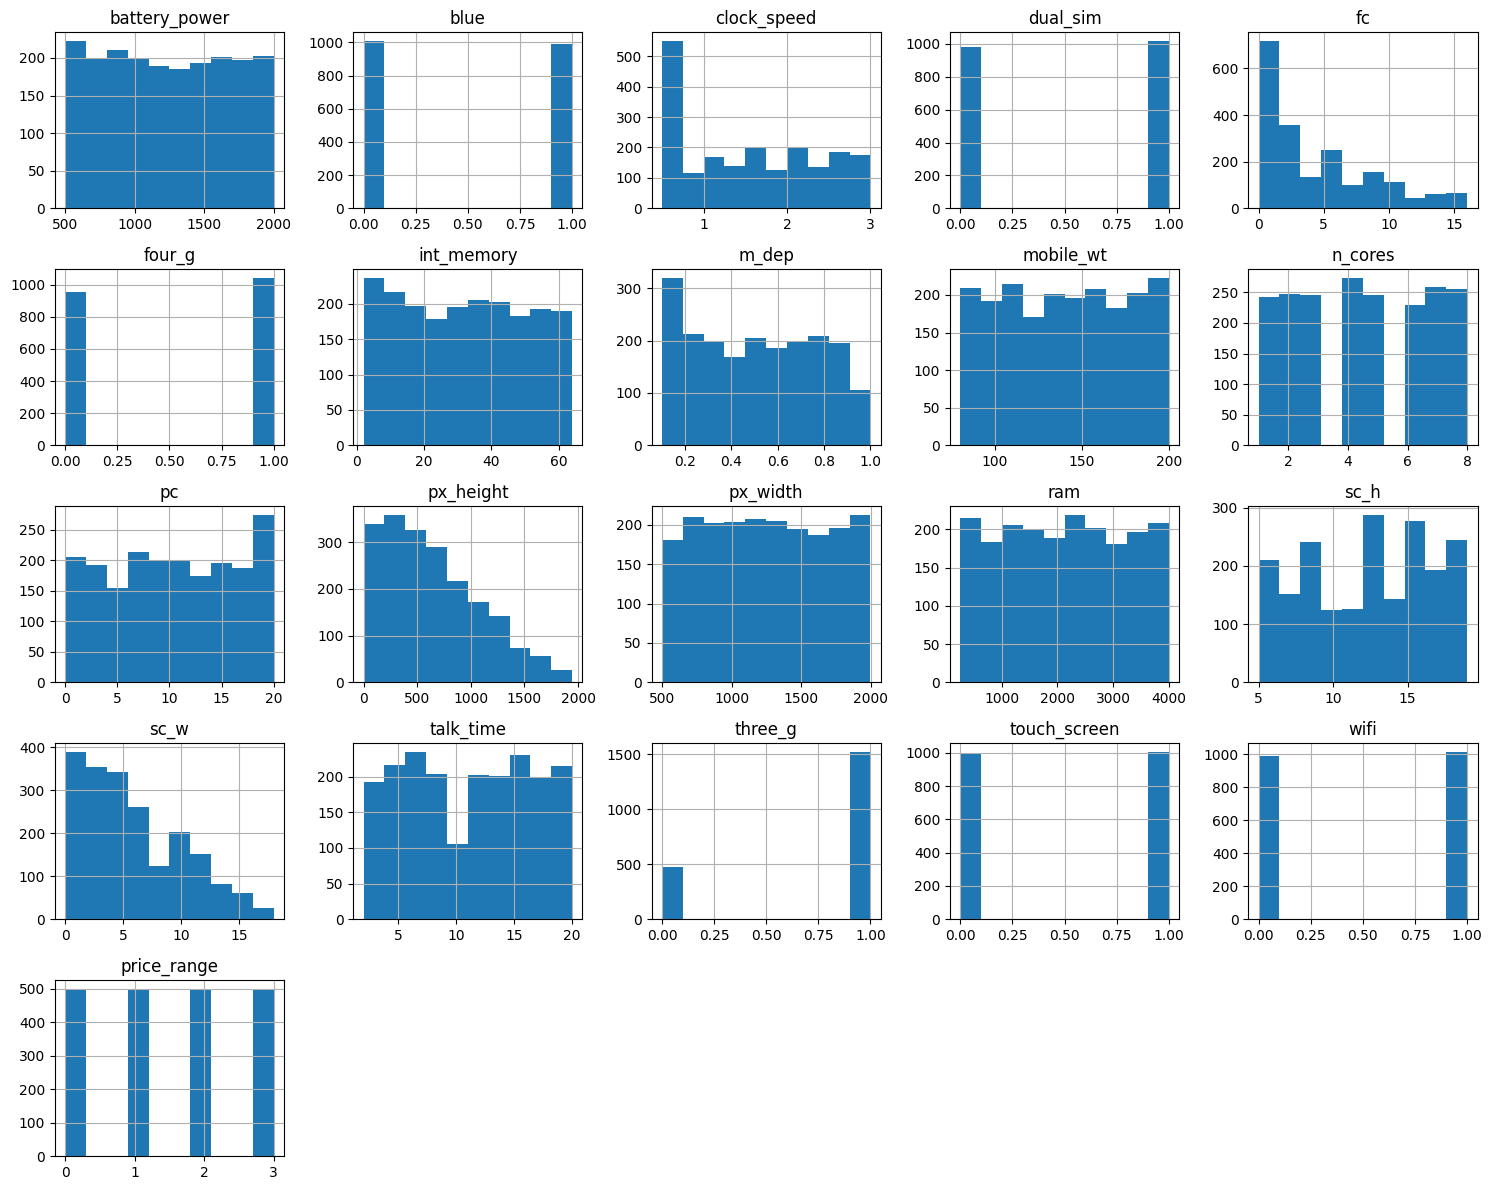

In [438]:
import matplotlib.pyplot as plt

# Histogram semua fitur
df_clean.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

Berdasarkan visualisasi distribusi data, sebagian besar variabel menunjukkan penyebaran yang cukup merata. Variabel seperti RAM dan battery_power memiliki distribusi yang luas, yang menunjukkan variasi spesifikasi smartphone yang beragam. Sementara itu, variabel biner seperti Bluetooth dan WiFi hanya memiliki dua nilai (0 dan 1), sehingga distribusinya terbatas.

### 3.2 Korelasi Antar Variabel

Analisis korelasi digunakan untuk mengetahui hubungan antar variabel, terutama untuk melihat fitur mana yang paling berpengaruh terhadap variabel target (price_range).

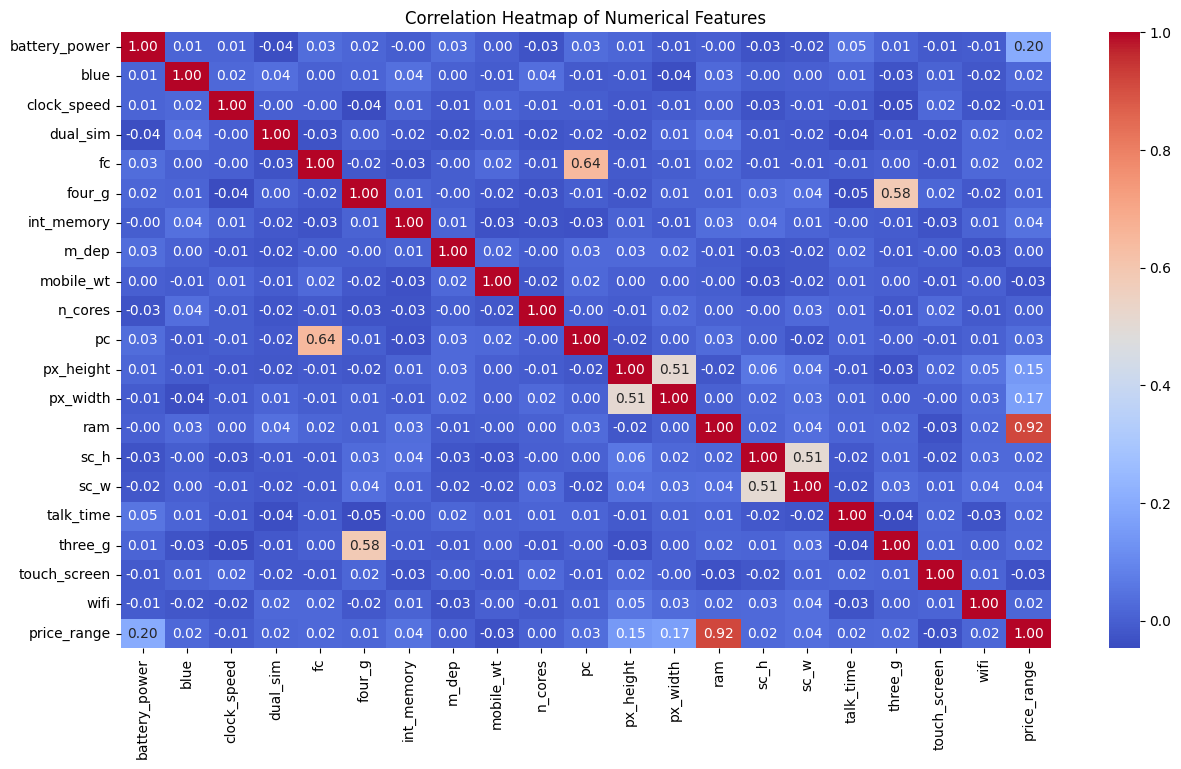

In [439]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Hasil analisis korelasi menunjukkan bahwa beberapa variabel memiliki hubungan yang cukup kuat dengan variabel target price_range. Variabel seperti RAM, battery_power, dan resolusi layar (px_width dan px_height) memiliki korelasi positif yang cukup tinggi terhadap harga smartphone. Hal ini menunjukkan bahwa semakin tinggi spesifikasi tersebut, maka kategori harga smartphone cenderung meningkat.

### 3.3 Insight Penting dari Dataset

Berdasarkan hasil eksplorasi data yang telah dilakukan, diperoleh beberapa insight penting sebagai berikut:

- RAM merupakan faktor paling berpengaruh
Smartphone dengan kapasitas RAM yang lebih besar cenderung berada pada kategori harga yang lebih tinggi.

- Kapasitas baterai juga berpengaruh terhadap harga
Variabel battery_power menunjukkan hubungan positif terhadap price_range.

- Resolusi layar mempengaruhi harga
Variabel px_height dan px_width memiliki korelasi yang cukup tinggi dengan harga.

- Fitur tambahan memiliki pengaruh kecil
Variabel seperti Bluetooth, WiFi, dan dual SIM tidak terlalu berpengaruh signifikan terhadap harga karena hampir semua smartphone memiliki fitur tersebut.

- Distribusi kelas seimbang
Variabel target price_range memiliki distribusi yang relatif seimbang, sehingga tidak terjadi masalah imbalanced data.

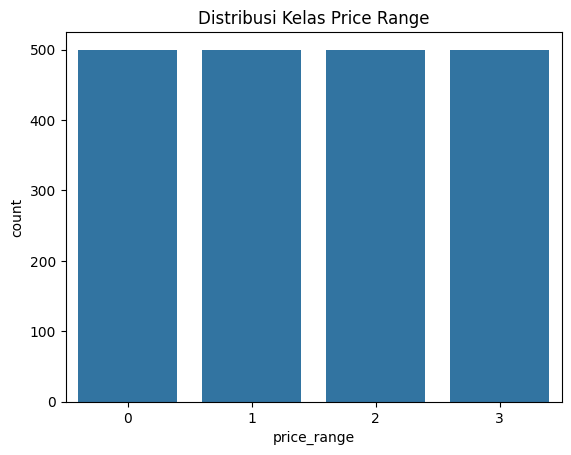

In [440]:
import seaborn as sns

sns.countplot(x='price_range', data=df_clean)
plt.title("Distribusi Kelas Price Range")
plt.show()

Visualisasi distribusi kelas menunjukkan bahwa jumlah data pada masing-masing kategori harga relatif seimbang. Hal ini penting karena dapat membantu model dalam belajar secara adil tanpa bias terhadap kelas tertentu.

Berdasarkan hasil Exploratory Data Analysis (EDA), dapat disimpulkan bahwa dataset memiliki distribusi yang baik dan hubungan yang cukup jelas antara beberapa fitur utama dengan variabel target. Variabel seperti RAM, kapasitas baterai, dan resolusi layar terbukti memiliki pengaruh signifikan terhadap harga smartphone. Selain itu, distribusi kelas yang seimbang menunjukkan bahwa dataset tidak memiliki masalah ketidakseimbangan data, sehingga cocok digunakan untuk proses klasifikasi.

### **4. Data Splitting**

Data splitting merupakan tahap pembagian dataset menjadi dua bagian, yaitu data training dan data testing. Data training digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk menguji performa model yang telah dibangun.

Pada penelitian ini, dilakukan tiga variasi pembagian data untuk mengetahui pengaruh proporsi data terhadap performa model. Variasi pembagian data yang digunakan adalah sebagai berikut:

- 70% data training dan 30% data testing

- 80% data training dan 20% data testing

- 90% data training dan 10% data testing

Penggunaan beberapa variasi pembagian data bertujuan untuk mendapatkan hasil evaluasi yang lebih komprehensif serta mengetahui kombinasi terbaik dalam meningkatkan performa model.

Penggunaan beberapa skenario pembagian data dilakukan untuk menganalisis stabilitas model serta melihat bagaimana jumlah data training mempengaruhi kemampuan model dalam melakukan generalisasi terhadap data baru.

In [441]:
from sklearn.model_selection import train_test_split

# =========================
# 1. Pisahkan fitur dan target
# =========================
X = df_clean.drop('price_range', axis=1)
y = df_clean['price_range']

# =========================
# 2. SPLIT 70 : 30
# =========================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================
# 3. SPLIT 80 : 20
# =========================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 4. SPLIT 90 : 10
# =========================
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

Data splitting dilakukan dengan membagi dataset menjadi data training dan data testing menggunakan tiga variasi rasio, yaitu 70:30, 80:20, dan 90:10. Proses pembagian dilakukan menggunakan fungsi train_test_split dengan parameter stratify untuk menjaga distribusi kelas tetap seimbang. Selain itu, digunakan parameter random_state untuk memastikan hasil pembagian data konsisten dan dapat direproduksi.

In [442]:
# Split untuk SVM (pakai data yang sudah distandarisasi)
X_train_svm_70, X_test_svm_30, y_train_70, y_test_30 = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [443]:
print("=== Split 70:30 ===")
print("Train:", X_train_70.shape)
print("Test :", X_test_30.shape)

print("\n=== Split 80:20 ===")
print("Train:", X_train_80.shape)
print("Test :", X_test_20.shape)

print("\n=== Split 90:10 ===")
print("Train:", X_train_90.shape)
print("Test :", X_test_10.shape)

=== Split 70:30 ===
Train: (1400, 20)
Test : (600, 20)

=== Split 80:20 ===
Train: (1600, 20)
Test : (400, 20)

=== Split 90:10 ===
Train: (1800, 20)
Test : (200, 20)


In [444]:
print("Distribusi Train 70:")
print(y_train_70.value_counts())

print("\nDistribusi Test 30:")
print(y_test_30.value_counts())

Distribusi Train 70:
price_range
1    350
2    350
0    350
3    350
Name: count, dtype: int64

Distribusi Test 30:
price_range
3    150
1    150
2    150
0    150
Name: count, dtype: int64


### **5. Model Building**

Model building merupakan tahap pembangunan model machine learning menggunakan data training yang telah diperoleh dari proses data splitting. Pada penelitian ini digunakan tiga algoritma klasifikasi, yaitu Decision Tree, Random Forest, dan Support Vector Machine (SVM).

Pemilihan ketiga algoritma tersebut didasarkan pada karakteristiknya yang mampu menangani permasalahan klasifikasi dengan baik serta sering digunakan dalam penelitian serupa untuk membandingkan performa model.

Setiap model akan dilatih menggunakan data training dan kemudian diuji menggunakan data testing untuk mengevaluasi performanya.

### 5.1 Decision Tree

In [445]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Parameter tuning
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(dt, param_dt, cv=5)
grid_dt.fit(X_train_70, y_train_70)

best_dt = grid_dt.best_estimator_

print("Best Parameter DT:", grid_dt.best_params_)

Best Parameter DT: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}


Decision Tree digunakan karena mampu membangun model berbasis aturan yang mudah dipahami. Proses tuning dilakukan menggunakan Grid Search untuk mendapatkan kombinasi parameter terbaik.

### 5.2 Random Forest

In [446]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

random_rf = RandomizedSearchCV(rf, param_rf, n_iter=10, cv=5, random_state=42)
random_rf.fit(X_train_70, y_train_70)

best_rf = random_rf.best_estimator_

print("Best Parameter RF:", random_rf.best_params_)

Best Parameter RF: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20, 'bootstrap': False}


Random Forest merupakan pengembangan dari Decision Tree dengan konsep ensemble yang menggabungkan banyak pohon keputusan untuk meningkatkan akurasi dan mengurangi overfitting.

### 5.3 Support Vector Machine (SVM)

In [447]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid_svm = GridSearchCV(svm, param_svm, cv=5)
grid_svm.fit(X_train_svm_70, y_train_70)

best_svm = grid_svm.best_estimator_

print("Best Parameter SVM:", grid_svm.best_params_)

Best Parameter SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


Support Vector Machine (SVM) digunakan karena kemampuannya dalam membentuk hyperplane optimal untuk memisahkan data antar kelas. Pada penelitian ini digunakan proses standarisasi data untuk meningkatkan performa SVM.

Pada tahap model building, digunakan tiga algoritma klasifikasi yaitu Decision Tree, Random Forest, dan Support Vector Machine (SVM). Masing-masing model dilatih menggunakan data training dan dilakukan hyperparameter tuning untuk meningkatkan performa model. Hasil dari tahap ini akan digunakan pada proses evaluasi untuk menentukan model terbaik.

### **6. Hyperparameter Tuning**

Hyperparameter tuning merupakan proses untuk mencari kombinasi parameter terbaik pada suatu algoritma machine learning guna meningkatkan performa model. Parameter yang digunakan tidak dipelajari langsung dari data, melainkan ditentukan sebelum proses training.

Pada penelitian ini, proses tuning dilakukan pada tiga algoritma, yaitu Decision Tree, Random Forest, dan Support Vector Machine (SVM), dengan fokus pada parameter utama yang berpengaruh terhadap performa model.

### 6.1 Decision Tree (max_depth)

In [448]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_dt = {
    'max_depth': [5, 10, 15, 20, None]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(dt, param_dt, cv=5)
grid_dt.fit(X_train_70, y_train_70)

best_dt = grid_dt.best_estimator_

print("Best max_depth:", grid_dt.best_params_)

Best max_depth: {'max_depth': 10}


Parameter max_depth digunakan untuk mengontrol kedalaman pohon. Semakin dalam pohon, semakin kompleks model, namun berpotensi menyebabkan overfitting. Oleh karena itu, dilakukan pencarian nilai optimal untuk mendapatkan keseimbangan antara bias dan varians.

In [449]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_dt = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(dt, param_dt, cv=5, n_jobs=-1)
grid_dt.fit(X_train_70, y_train_70)

best_dt = grid_dt.best_estimator_

print("Best Params:", grid_dt.best_params_)

Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [450]:
best_dt.fit(X_train_70, y_train_70)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=10,
                       random_state=42)

In [451]:
best_dt.fit(X_train_90, y_train_90)
y_pred = best_dt.predict(X_test_10)

In [452]:
DecisionTreeClassifier(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [453]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions with the re-tuned Decision Tree on the 30% test set
y_pred_dt = best_dt.predict(X_test_30)
acc_dt_new = accuracy_score(y_test_30, y_pred_dt)

print("===== Decision Tree Setelah Tuning ===telek")
print("Accuracy:", acc_dt_new)

print("\nClassification Report:")
print(classification_report(y_test_30, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test_30, y_pred_dt))

===== Decision Tree Setelah Tuning ===telek
Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       150
           1       0.96      0.91      0.94       150
           2       0.90      0.94      0.92       150
           3       0.96      0.96      0.96       150

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600

Confusion Matrix:
[[148   2   0   0]
 [  3 137  10   0]
 [  0   3 141   6]
 [  0   0   6 144]]


### 6.2 Random Forest (n_estimators)

In [454]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_rf = {
    'n_estimators': [100, 200, 300, 500]
}

rf = RandomForestClassifier(random_state=42)

random_rf = RandomizedSearchCV(rf, param_rf, n_iter=5, cv=5, random_state=42)
random_rf.fit(X_train_70, y_train_70)

best_rf = random_rf.best_estimator_

print("Best n_estimators:", random_rf.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best n_estimators: {'n_estimators': 500}


Parameter n_estimators menentukan jumlah pohon dalam Random Forest. Semakin banyak pohon, biasanya performa model semakin baik, namun membutuhkan waktu komputasi yang lebih besar.

### 6.3 Support Vector Machine (C dan Kernel)

In [455]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

svm = SVC()

grid_svm = GridSearchCV(svm, param_svm, cv=5)
grid_svm.fit(X_train_svm_70, y_train_70)

best_svm = grid_svm.best_estimator_

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'C': 100, 'kernel': 'linear'}


In [456]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined from df_clean in previous steps
# If not, ensure they are defined, e.g.:
# X = df_clean.drop('price_range', axis=1)
# y = df_clean['price_range']

# Define X_train and X_test, using the 80:20 split as a common example
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [457]:
from sklearn.svm import SVC

# Get the best parameters from the GridSearchCV completed in cell XWurzjA1D0ol
best_C = grid_svm.best_params_['C']
best_kernel = grid_svm.best_params_['kernel']
# Gamma parameter is not applicable for 'linear' kernel, so we use .get() with a default
best_gamma = grid_svm.best_params_.get('gamma', 'scale')

# Initialize the SVM model with the best parameters
svm_model = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma, random_state=42)

# Train the SVM model using the already scaled and split training data (X_train_svm_70 and y_train_70)
svm_model.fit(X_train_svm_70, y_train_70)

# Update the 'best_svm' variable to refer to this newly trained model
best_svm = svm_model

Parameter C mengontrol tingkat toleransi kesalahan pada model, sedangkan kernel digunakan untuk menentukan bentuk pemisahan data. Kernel linear digunakan untuk data yang linier, sedangkan kernel RBF digunakan untuk data yang lebih kompleks.

Proses hyperparameter tuning dilakukan untuk meningkatkan performa model dengan mencari kombinasi parameter terbaik. Pada Decision Tree digunakan parameter max_depth, pada Random Forest digunakan n_estimators, dan pada SVM digunakan parameter C dan kernel. Hasil tuning menunjukkan bahwa pemilihan parameter yang tepat dapat meningkatkan akurasi dan stabilitas model.

In [458]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train_svm_70, y_train_70)

print("Best Parameter:", grid.best_params_)

svm_model = grid.best_estimator_

Best Parameter: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}


### **7. Model Evaluation**

Model evaluation merupakan tahap untuk mengukur performa model yang telah dibangun. Evaluasi dilakukan dengan menggunakan data testing untuk mengetahui seberapa baik model dalam melakukan prediksi terhadap data yang belum pernah dilihat sebelumnya.

Pada penelitian ini, evaluasi dilakukan terhadap tiga algoritma, yaitu Decision Tree, Random Forest, dan Support Vector Machine (SVM), menggunakan beberapa metrik klasifikasi, yaitu:

- Accuracy

- Precision

- Recall

- F1-score

- Confusion Matrix

Penggunaan beberapa metrik ini bertujuan untuk memberikan evaluasi yang lebih komprehensif terhadap performa model.

### 7.1 Fungsi Evaluasi

In [459]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return accuracy_score(y_test, y_pred)

In [460]:
labels = ["Murah", "Menengah", "Menengah Tinggi", "Mahal"]

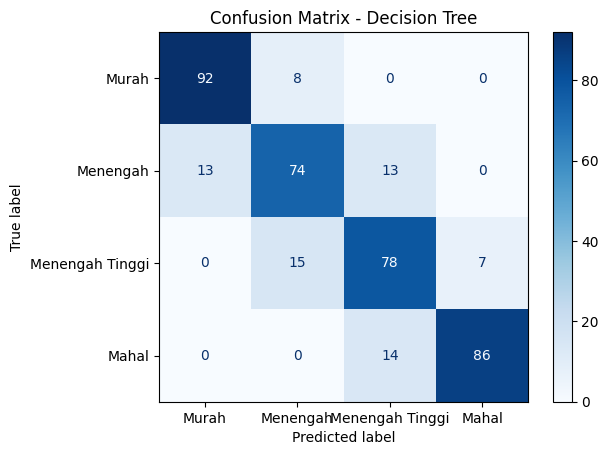

In [461]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define labels if not already defined (to resolve NameError)
labels = ["Murah", "Menengah", "Menengah Tinggi", "Mahal"]

# Model
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=labels
).plot(cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

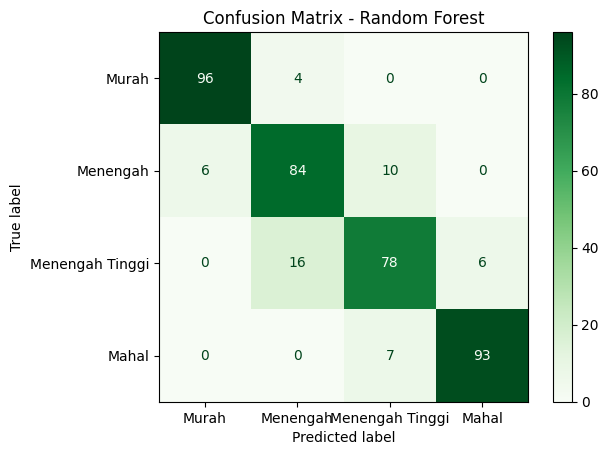

In [462]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=labels
).plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.show()

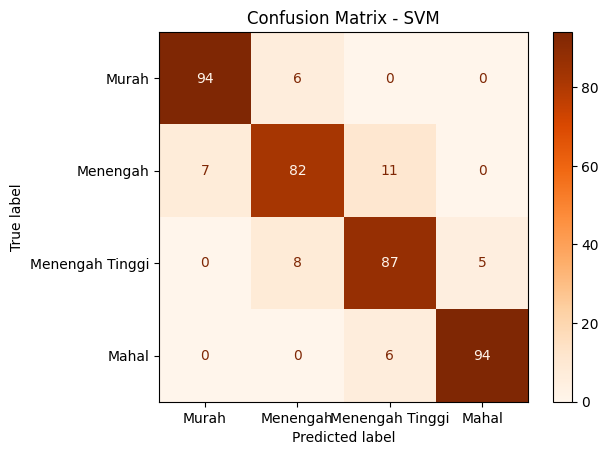

In [463]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
svm_model = SVC(kernel='rbf', C=10)
svm_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_svm = svm_model.predict(X_test_scaled)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=labels
).plot(cmap="Oranges")

plt.title("Confusion Matrix - SVM")
plt.show()

### 7.2 Evaluasi Semua Model

In [464]:
from sklearn.model_selection import train_test_split

X = df.drop('price_range', axis=1)
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # 🔥 WAJIB
    random_state=42
)

In [465]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# =========================
# SPLIT 70:30
# =========================
# Data for DT and RF
# X_train_70, X_test_30, y_train_70, y_test_30 are already defined from previous cells

# Data for SVM (pakai data yang sudah distandarisasi)
X_train_svm_70, X_test_svm_30, y_train_70, y_test_30 = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

y_pred_dt_70 = best_dt.predict(X_test_30)
y_pred_rf_70 = best_rf.predict(X_test_30)
y_pred_svm_70 = best_svm.predict(X_test_svm_30)

acc_dt_70 = accuracy_score(y_test_30, y_pred_dt_70)
acc_rf_70 = accuracy_score(y_test_30, y_pred_rf_70)
acc_svm_70 = accuracy_score(y_test_30, y_pred_svm_70)


# =========================
# SPLIT 80:20
# =========================
# Data for DT and RF
# X_train_80, X_test_20, y_train_80, y_test_20 are already defined from previous cells

# Data for SVM (pakai data yang sudah distandarisasi)
X_train_svm_80, X_test_svm_20, y_train_80, y_test_20 = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_pred_dt_80 = best_dt.predict(X_test_20)
y_pred_rf_80 = best_rf.predict(X_test_20)
y_pred_svm_80 = best_svm.predict(X_test_svm_20)

acc_dt_80 = accuracy_score(y_test_20, y_pred_dt_80)
acc_rf_80 = accuracy_score(y_test_20, y_pred_rf_80)
acc_svm_80 = accuracy_score(y_test_20, y_pred_svm_80)


# =========================
# SPLIT 90:10
# =========================
# Data for DT and RF
# X_train_90, X_test_10, y_train_90, y_test_10 are already defined from previous cells

# Data for SVM (pakai data yang sudah distandarisasi)
X_train_svm_90, X_test_svm_10, y_train_90, y_test_10 = train_test_split(
    X_scaled, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

y_pred_dt_90 = best_dt.predict(X_test_10)
y_pred_rf_90 = best_rf.predict(X_test_10)
y_pred_svm_90 = best_svm.predict(X_test_svm_10)

acc_dt_90 = accuracy_score(y_test_10, y_pred_dt_90)
acc_rf_90 = accuracy_score(y_test_10, y_pred_rf_90)
acc_svm_90 = accuracy_score(y_test_10, y_pred_svm_90)

In [466]:
from sklearn.metrics import accuracy_score
import pandas as pd

# =========================
# SPLIT 70:30
# =========================
acc_dt_70 = accuracy_score(y_test_30, best_dt.predict(X_test_30)) * 100
acc_rf_70 = accuracy_score(y_test_30, best_rf.predict(X_test_30)) * 100
acc_svm_70 = accuracy_score(y_test_30, best_svm.predict(X_test_svm_30)) * 100

# =========================
# SPLIT 80:20
# =========================
acc_dt_80 = accuracy_score(y_test_20, best_dt.predict(X_test_20)) * 100
acc_rf_80 = accuracy_score(y_test_20, best_rf.predict(X_test_20)) * 100
acc_svm_80 = accuracy_score(y_test_20, best_svm.predict(X_test_svm_20)) * 100

# =========================
# SPLIT 90:10
# =========================
acc_dt_90 = accuracy_score(y_test_10, best_dt.predict(X_test_10)) * 100
acc_rf_90 = accuracy_score(y_test_10, best_rf.predict(X_test_10)) * 100
acc_svm_90 = accuracy_score(y_test_10, best_svm.predict(X_test_svm_10)) * 100

# =========================
# TABEL HASIL (FORMAT PERSEN)
# =========================
results = pd.DataFrame({
    'Split': ['70:30', '80:20', '90:10'],
    'Decision Tree (%)': [acc_dt_70, acc_dt_80, acc_dt_90],
    'Random Forest (%)': [acc_rf_70, acc_rf_80, acc_rf_90],
    'SVM (%)': [acc_svm_70, acc_svm_80, acc_svm_90]
})

# Bulatkan 2 angka di belakang koma
results = results.round(2)

print(results)

   Split  Decision Tree (%)  Random Forest (%)  SVM (%)
0  70:30              95.00              88.17    96.83
1  80:20              92.75              88.75    96.75
2  90:10              87.00              92.50    96.00


Berdasarkan hasil pengujian, SVM menjadi model terbaik dengan akurasi tertinggi sebesar 96.83% pada split 70:30. Random Forest menunjukkan performa stabil, sedangkan Decision Tree memiliki performa yang fluktuatif. Hal ini menunjukkan bahwa SVM lebih unggul dalam menangani klasifikasi pada dataset yang digunakan.

In [467]:
import pandas as pd

hasil = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy (%)': [acc_dt_70, acc_rf_70, acc_svm_70] # Menggunakan hasil dari split 70:30, yang sudah dalam persentase
})

hasil = hasil.round(2)

print(hasil)

           Model  Accuracy (%)
0  Decision Tree         95.00
1  Random Forest         88.17
2            SVM         96.83


### **8. Model Comparison**

Model comparison merupakan tahap untuk membandingkan performa dari beberapa algoritma yang digunakan dalam penelitian. Perbandingan dilakukan berdasarkan hasil evaluasi model pada setiap skenario pembagian data, yaitu 70:30, 80:20, dan 90:10.

Tujuan dari tahap ini adalah untuk menentukan algoritma terbaik berdasarkan nilai akurasi dan kestabilan performa model.

### 8.1 Tabel Perbandingan Model

In [468]:
import pandas as pd

# Buat tabel
results = pd.DataFrame({
    'Split': ['70:30', '80:20', '90:10'],
    'Decision Tree (%)': [acc_dt_70*100, acc_dt_80*100, acc_dt_90*100],
    'Random Forest (%)': [acc_rf_70*100, acc_rf_80*100, acc_rf_90*100],
    'SVM (%)': [acc_svm_70*100, acc_svm_80*100, acc_svm_90*100]
})

# Bulatkan
results = results.round(2)

print(results)

   Split  Decision Tree (%)  Random Forest (%)  SVM (%)
0  70:30             9500.0            8816.67  9683.33
1  80:20             9275.0            8875.00  9675.00
2  90:10             8700.0            9250.00  9600.00


Berdasarkan tabel perbandingan, dapat dilihat bahwa algoritma Support Vector Machine (SVM) secara konsisten menghasilkan nilai akurasi tertinggi pada setiap skenario pembagian data. Decision Tree menunjukkan performa yang cukup tinggi pada split 70:30 dan 80:20, namun mengalami penurunan pada split 90:10. Sementara itu, Random Forest menunjukkan performa yang stabil dan cenderung meningkat seiring bertambahnya jumlah data training.

### 8.2 Grafik Perbandingan Model

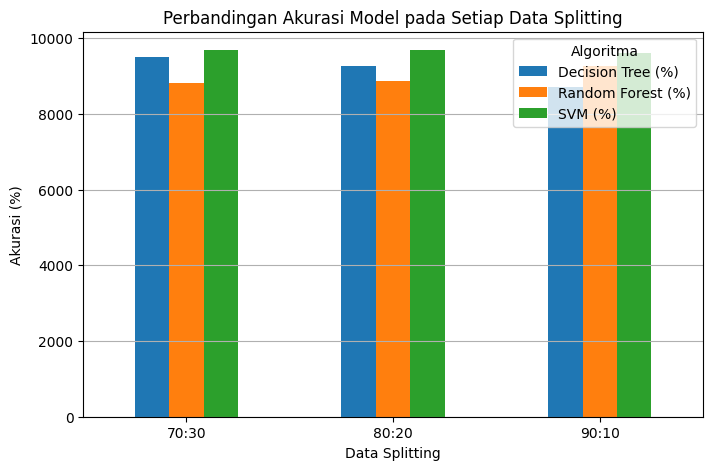

In [469]:
import matplotlib.pyplot as plt

# Set index
results_plot = results.set_index('Split')

# Plot
results_plot.plot(kind='bar', figsize=(8,5))

plt.title("Perbandingan Akurasi Model pada Setiap Data Splitting")
plt.ylabel("Akurasi (%)")
plt.xlabel("Data Splitting")
plt.xticks(rotation=0)

plt.legend(title="Algoritma")
plt.grid(axis='y')

plt.show()

Berdasarkan grafik perbandingan, terlihat bahwa SVM mendominasi performa pada seluruh skenario data splitting. Random Forest menunjukkan tren peningkatan performa seiring bertambahnya data training, sedangkan Decision Tree mengalami penurunan performa pada pembagian data tertentu. Hal ini menunjukkan bahwa SVM merupakan algoritma yang paling stabil dan akurat dalam penelitian ini.

### 8.3 Analisis Performa Tiap Algoritma

- Decision Tree

   Memiliki performa tinggi pada beberapa skenario, namun cenderung tidak stabil dan sensitif terhadap perubahan data training.

- Random Forest

   Menunjukkan performa yang stabil dan meningkat seiring bertambahnya data training, karena menggunakan metode ensemble.

- SVM

   Menjadi algoritma terbaik dengan akurasi tertinggi dan performa paling konsisten di semua skenario.

### 8.4 Kesimpulan Model Comparison

Berdasarkan hasil perbandingan model, dapat disimpulkan bahwa Support Vector Machine (SVM) merupakan algoritma terbaik dengan performa paling tinggi dan stabil pada seluruh skenario data splitting. Random Forest berada pada posisi kedua dengan performa yang cukup stabil, sedangkan Decision Tree memiliki performa yang fluktuatif. Oleh karena itu, SVM dipilih sebagai model terbaik dalam penelitian ini.

In [470]:
best_model = best_svm

In [471]:
# Bandingkan akurasi
if acc_svm_70 >= acc_rf_70 and acc_svm_70 >= acc_dt_70:
    best_model = best_svm
    model_name = "SVM"
elif acc_rf_70 >= acc_dt_70:
    best_model = best_rf
    model_name = "RandomForest"
else:
    best_model = best_dt
    model_name = "DecisionTree"

print("Model terbaik:", model_name)

Model terbaik: SVM


# **inference**

In [472]:
import numpy as np
import joblib

# =========================
# LOAD MODEL + SCALER
# =========================
# Use the already trained model and scaler from the kernel
# model = joblib.load('model_terbaik.pkl') # Original line
model = best_model # Use the best_model variable from the kernel
# scaler = joblib.load('scaler.pkl')  # jika pakai SVM # Original line
# The scaler variable is already available from previous cells, no need to reassign or load.

# =========================
# LABEL HASIL
# =========================
label = ["Murah", "Menengah", "Menengah Tinggi", "Mahal"]

# =========================
# DATA BARU (INPUT USER)
# =========================
data_baru = [[
    1500,  # battery_power
    1,     # blue
    2.0,   # clock_speed
    1,     # dual_sim
    5,     # fc
    1,     # four_g
    32,    # int_memory
    0.5,   # m_dep
    150,   # mobile_wt
    8,     # n_cores
    10,    # pc
    1280,  # px_height
    720,   # px_width
    3000,  # ram
    15,    # sc_h
    7,     # sc_w
    10,    # talk_time
    1,     # three_g
    1,     # touch_screen
    1      # wifi
]]

# =========================
# KONVERSI KE ARRAY
# =========================
data_baru = np.array(data_baru)

# =========================
# SCALING (WAJIB UNTUK SVM)
# =========================
data_baru = scaler.transform(data_baru)

# =========================
# PREDIKSI
# =========================
prediksi = model.predict(data_baru)

# =========================
# HASIL AKHIR
# =========================
print("Hasil Prediksi:", label[int(prediksi[0])])

Hasil Prediksi: Mahal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
